In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
df = pd.read_csv("Medical insurance mini project regression.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


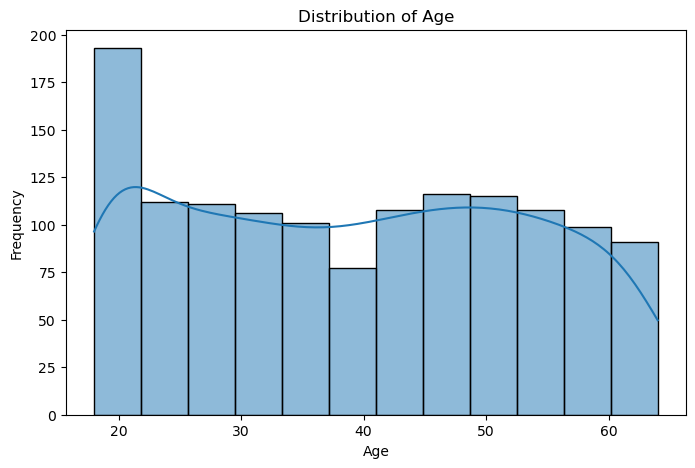

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

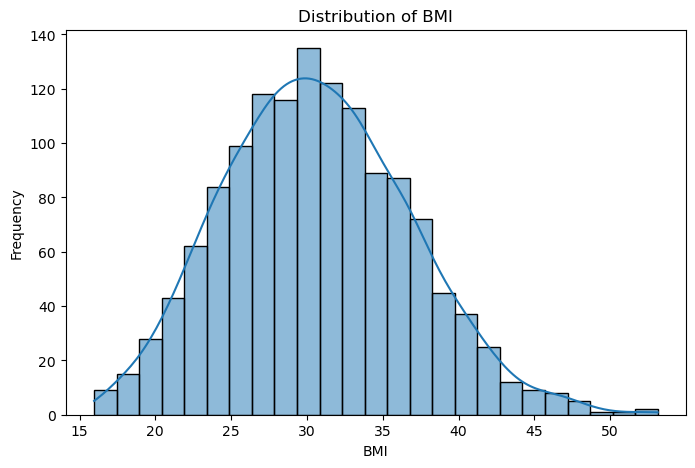

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='bmi', kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

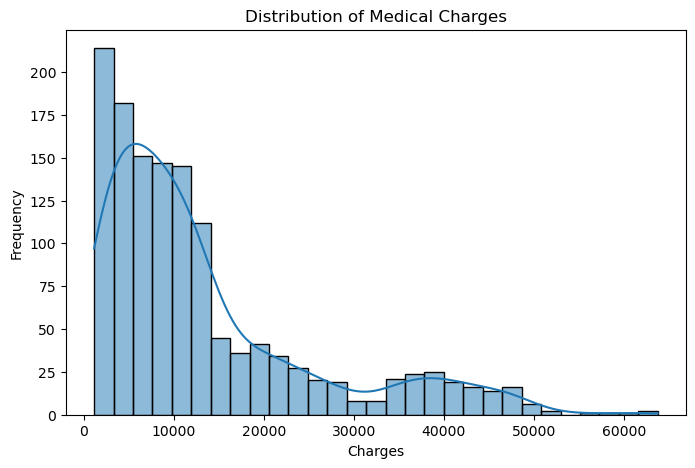

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='charges', kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

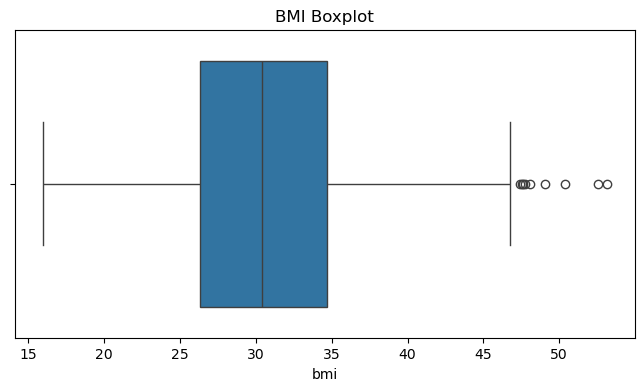

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['bmi'])

plt.title("BMI Boxplot")

plt.show()

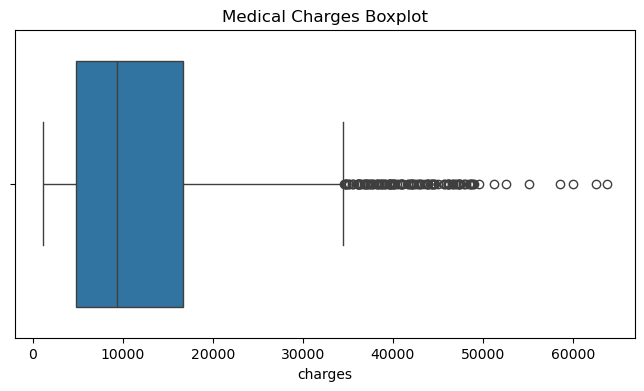

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['charges'])

plt.title("Medical Charges Boxplot")

plt.show()

In [ ]:
numerical_columns = ['age', 'bmi', 'children', 'charges']

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


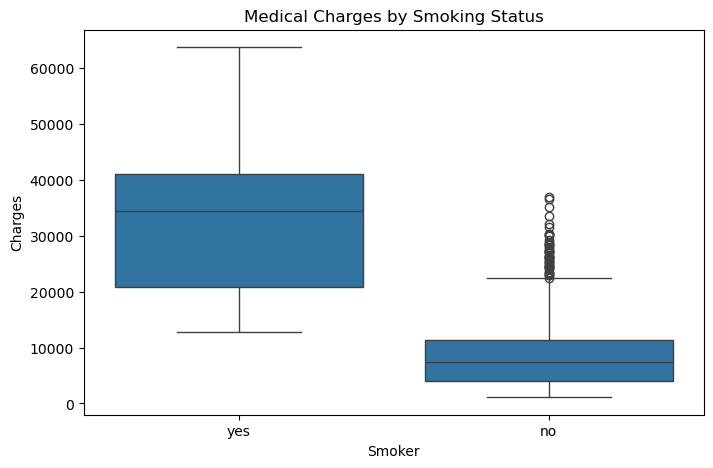

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='smoker', y='charges')

plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

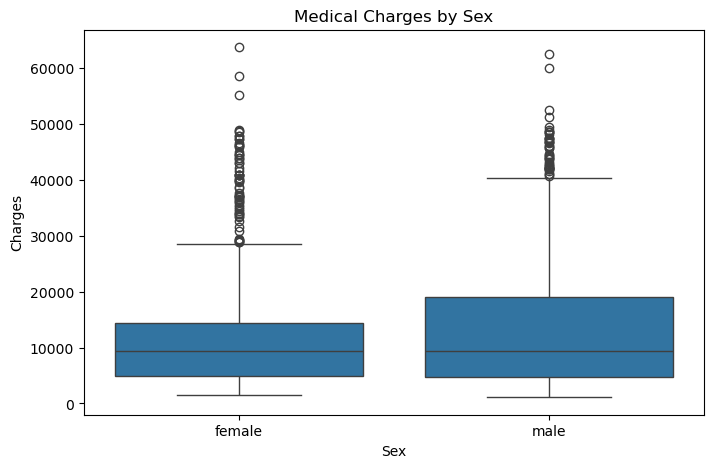

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='sex', y='charges')

plt.title("Medical Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")

plt.show()

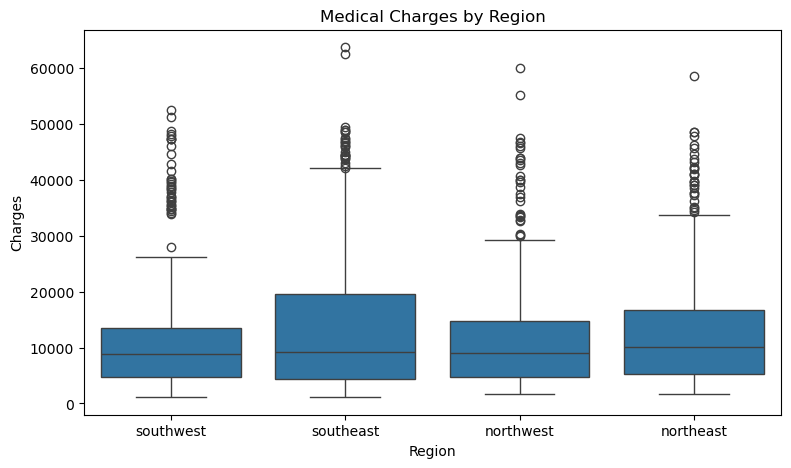

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x='region', y='charges')

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

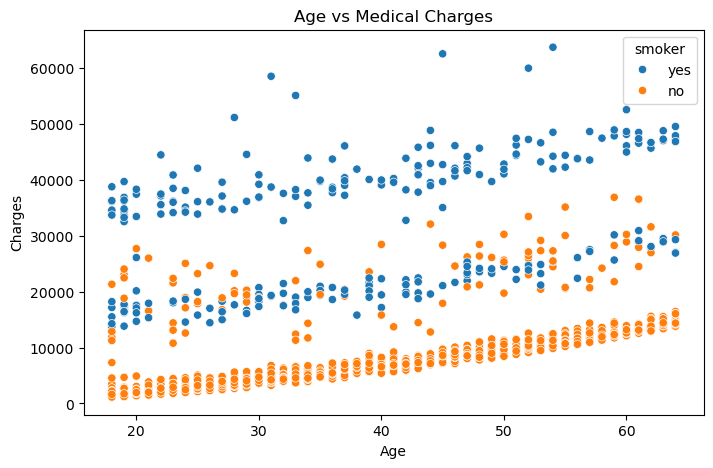

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker'
)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

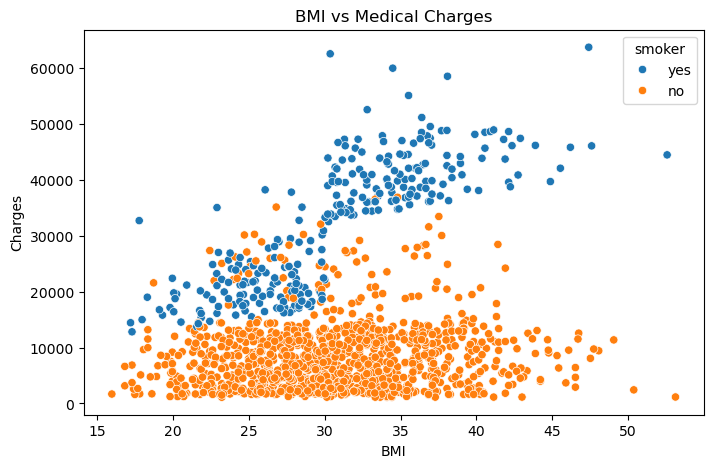

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker'
)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

In [ ]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

print(correlation_matrix)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


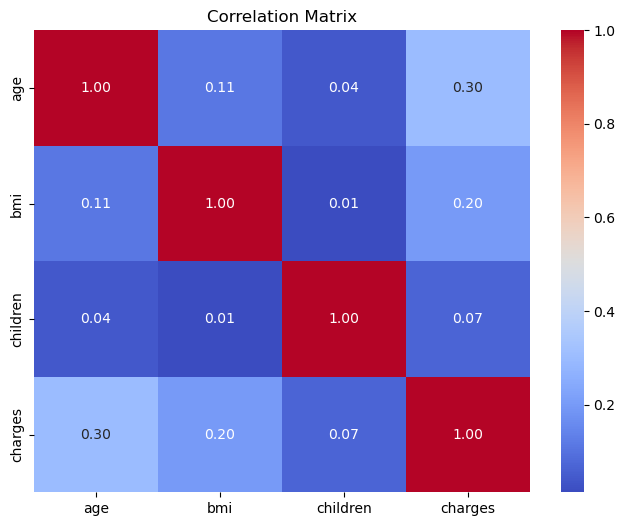

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
correlation_matrix['charges'].sort_values(ascending=False)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64

In [ ]:
skewness = df.select_dtypes(include=np.number).skew()

print(skewness)

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64


In [ ]:
X = df.drop('charges', axis=1)

y = df['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
numerical_features = [
    'age',
    'bmi',
    'children'
]

categorical_features = [
    'sex',
    'smoker',
    'region'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [ ]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [ ]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [ ]:
y_train_pred = linear_model.predict(X_train)

y_test_pred = linear_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_test_pred)

print("MAE:", mae)

MAE: 4177.045561036324


In [ ]:
mse = mean_squared_error(y_test, y_test_pred)

print("MSE:", mse)

MSE: 35478020.6752356


In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5956.342894363587


In [ ]:
r2 = r2_score(y_test, y_test_pred)

print("R²:", r2)

R²: 0.8069287081198012


In [ ]:
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

In [ ]:
p = len(
    linear_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

train_r2 = r2_score(
    y_train,
    linear_model.predict(X_train)
)

test_r2 = r2_score(
    y_test,
    linear_model.predict(X_test)
)

train_adj_r2 = adjusted_r2(
    train_r2,
    len(y_train),
    p
)

test_adj_r2 = adjusted_r2(
    test_r2,
    len(y_test),
    p
)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Training metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    train_mse = mean_squared_error(y_train, train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, train_pred)

    # Testing metrics
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_pred)

    # Number of predictors after preprocessing
    p = len(
        model
        .named_steps['preprocessor']
        .get_feature_names_out()
    )

    # Adjusted R2
    train_adj_r2 = adjusted_r2(
        train_r2,
        len(y_train),
        p
    )

    test_adj_r2 = adjusted_r2(
        test_r2,
        len(y_test),
        p
    )

    return {
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train Adjusted R2': train_adj_r2,
        'Test Adjusted R2': test_adj_r2
    }

In [ ]:
models = {}

models['Linear Regression'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [ ]:
models['Decision Tree'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

In [ ]:
models['Random Forest'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
models['SVR'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            SVR(
                kernel='rbf',
                C=100,
                gamma='scale',
                epsilon=0.1
            )
        )
    ]
)

In [ ]:
models['KNN'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            KNeighborsRegressor(
                n_neighbors=10,
                weights='distance'
            )
        )
    ]
)

In [ ]:
models['Gradient Boosting'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=2,
                random_state=42
            )
        )
    ]
)

In [ ]:
models['Extra Trees'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            ExtraTreesRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    metrics = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    metrics['Model'] = model_name

    results.append(metrics)

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'Train RMSE',
        'Test RMSE',
        'Train R2',
        'Test R2',
        'Train Adjusted R2',
        'Test Adjusted R2'
    ]
]

results_df

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,0.727867,0.800965
1,Decision Tree,0.000000e+00,5912.108673,1.000000,0.809786,1.000000,0.803910
2,Random Forest,1.843022e+03,4700.173068,0.975191,0.879777,0.975004,0.876064
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,0.003503,-0.054054
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,1.000000,0.619791
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,0.867240,0.896304
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,1.000000,0.847468


In [ ]:
results_df['R2 Gap'] = (
    results_df['Train R2']
    - results_df['Test R2']
)

In [ ]:
results_df['Overfitting'] = np.where(
    results_df['R2 Gap'] > 0.10,
    'Y',
    'N'
)

In [ ]:
comparison_table = results_df[
    [
        'Model',
        'Train RMSE',
        'Test RMSE',
        'Train R2',
        'Test R2',
        'Overfitting'
    ]
]

comparison_table.sort_values(
    by='Test RMSE'
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843022e+03,4700.173068,0.975191,0.879777,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5912.108673,1.000000,0.809786,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [ ]:
best_model = models['Gradient Boosting']

best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)

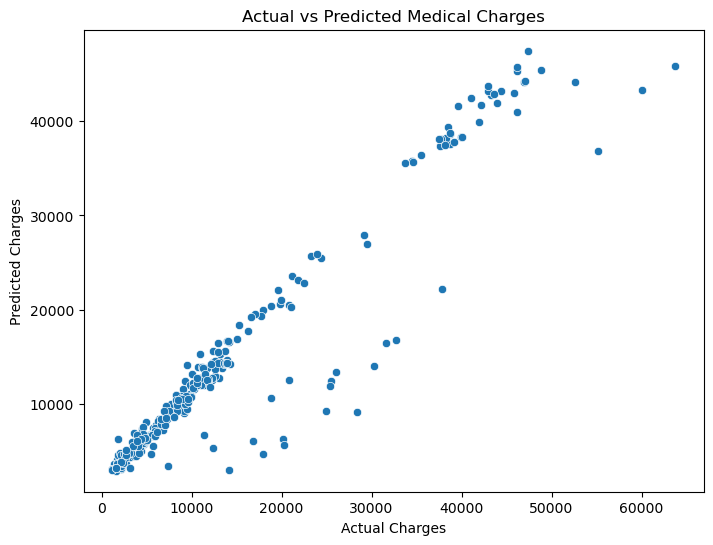

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Medical Charges")

plt.show()

In [ ]:
residuals = y_test - y_test_pred

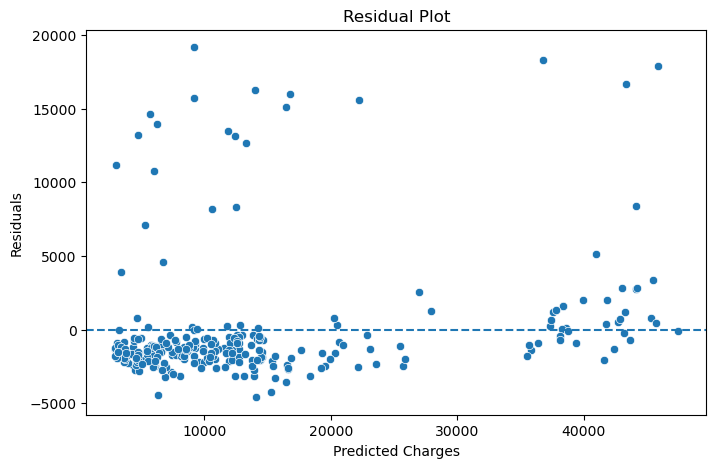

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [ ]:
gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [ ]:
gb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__min_samples_leaf': [3, 5]
}

In [ ]:
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [ ]:
grid_search_gb.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [2, 3],
                         'model__min_samples_leaf': [3, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print(
    "Best Parameters:",
    grid_search_gb.best_params_
)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [ ]:
print(
    "Best Parameters:",
    grid_search_gb.best_params_
)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [ ]:
best_gb_model = grid_search_gb.best_estimator_

In [ ]:
tuned_gb_metrics = evaluate_model(
    best_gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

tuned_gb_metrics

{'Train MAE': 2329.504871250882,
 'Test MAE': 2482.1426547071774,
 'Train MSE': 17771944.455306377,
 'Test MSE': 18076046.428326115,
 'Train RMSE': np.float64(4215.678409853671),
 'Test RMSE': np.float64(4251.593398753709),
 'Train R2': 0.870196930396562,
 'Test R2': 0.9016302045722792,
 'Train Adjusted R2': 0.8692172845882341,
 'Test Adjusted R2': 0.8985917552926584}

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
rf_param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt']
}

In [ ]:
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [ ]:
grid_search_rf.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 15],
                         'model__max_features': [1.0, 'sqrt'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__n_estimators': [200, 400]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print(
    grid_search_rf.best_params_
)

{'model__max_depth': 10, 'model__max_features': 1.0, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [ ]:
best_rf_model = grid_search_rf.best_estimator_

In [ ]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
voting_model = VotingRegressor(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('gb', gb_pipe)
    ]
)

In [ ]:
voting_model.fit(
    X_train,
    y_train
)

VotingRegressor(estimators=[('lr',
                             Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'bmi',
                                                                                'children']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['sex',
                                                                                'smoker',
                                                                                'region'])])),
                                             ('model', LinearRegression())])),
                            ('rf',
                             Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Stan...
                                                                                'region'])])),
                                             ('model',
                                              RandomForestRegressor(n_estimators=200,
                                                                    n_jobs=-1,
                                                                    random_state=42))])),
                            ('gb',
                             Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'bmi',
                                                                                'children']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['sex',
                                                                                'smoker',
                                                                                'region'])])),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]))])

In [ ]:
voting_pred = voting_model.predict(X_test)

In [ ]:
voting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        voting_pred
    )
)

voting_r2 = r2_score(
    y_test,
    voting_pred
)

print("Voting RMSE:", voting_rmse)
print("Voting R²:", voting_r2)

Voting RMSE: 4479.048727121329
Voting R²: 0.8908233172895992


In [ ]:
stacking_model = StackingRegressor(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('gb', gb_pipe)
    ],
    final_estimator=LinearRegression()
)

In [ ]:
stacking_model.fit(
    X_train,
    y_train
)

StackingRegressor(estimators=[('lr',
                               Pipeline(steps=[('preprocessor',
                                                ColumnTransformer(transformers=[('num',
                                                                                 StandardScaler(),
                                                                                 ['age',
                                                                                  'bmi',
                                                                                  'children']),
                                                                                ('cat',
                                                                                 OneHotEncoder(drop='first',
                                                                                               handle_unknown='ignore'),
                                                                                 ['sex',
                                                                                  'smoker',
                                                                                  'region'])])),
                                               ('model', LinearRegression())])),
                              ('rf',
                               Pipeline(steps=[('preprocessor',
                                                ColumnTransformer(transformers=[('num',
                                                                                 St...
                                                RandomForestRegressor(n_estimators=200,
                                                                      n_jobs=-1,
                                                                      random_state=42))])),
                              ('gb',
                               Pipeline(steps=[('preprocessor',
                                                ColumnTransformer(transformers=[('num',
                                                                                 StandardScaler(),
                                                                                 ['age',
                                                                                  'bmi',
                                                                                  'children']),
                                                                                ('cat',
                                                                                 OneHotEncoder(drop='first',
                                                                                               handle_unknown='ignore'),
                                                                                 ['sex',
                                                                                  'smoker',
                                                                                  'region'])])),
                                               ('model',
                                                GradientBoostingRegressor(random_state=42))]))],
                  final_estimator=LinearRegression())

In [ ]:
stacking_pred = stacking_model.predict(X_test)

In [ ]:
stacking_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        stacking_pred
    )
)

stacking_r2 = r2_score(
    y_test,
    stacking_pred
)

print("Stacking RMSE:", stacking_rmse)
print("Stacking R²:", stacking_r2)

Stacking RMSE: 4268.286802684639
Stacking R²: 0.9008562121471153


In [ ]:
comparison_table.sort_values(
    by='Test RMSE',
    ascending=True
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843022e+03,4700.173068,0.975191,0.879777,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5912.108673,1.000000,0.809786,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [ ]:
comparison_table.sort_values(
    by='Test R2',
    ascending=False
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843022e+03,4700.173068,0.975191,0.879777,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5912.108673,1.000000,0.809786,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [ ]:
gb_model = (
    best_gb_model
    .named_steps['model']
)

In [ ]:
feature_names = (
    best_gb_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [ ]:
importance = gb_model.feature_importances_

In [ ]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [ ]:
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [ ]:
feature_importance_df

,Feature,Importance
4,cat__smoker_yes,0.688549
1,num__bmi,0.177191
0,num__age,0.121398
2,num__children,0.011464
7,cat__region_southwest,0.000737
3,cat__sex_male,0.000334
6,cat__region_southeast,0.000194
5,cat__region_northwest,0.000134


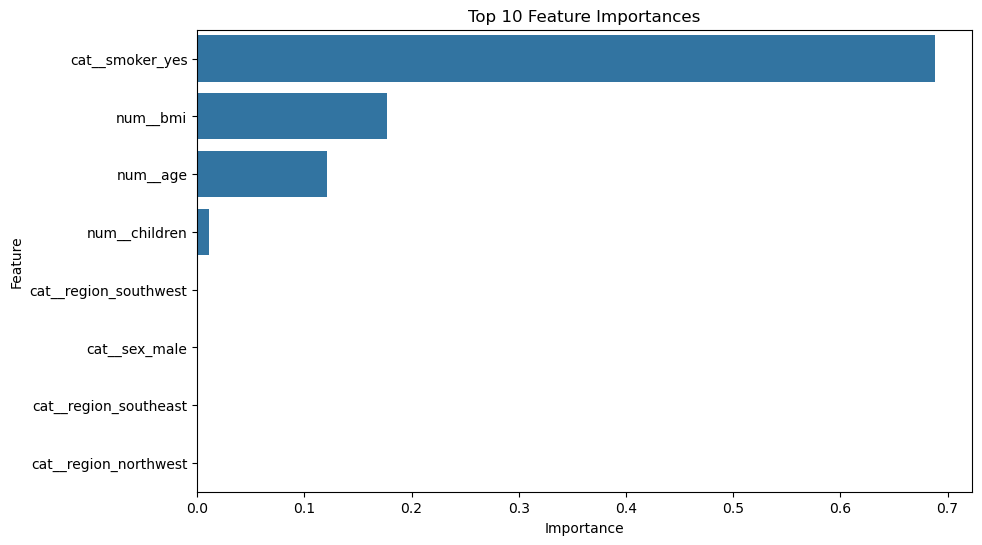

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

In [ ]:
final_model = best_gb_model

In [ ]:
def predict_insurance_cost(
    age,
    sex,
    bmi,
    children,
    smoker,
    region
):

    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    prediction = final_model.predict(
        input_data
    )

    return prediction[0]

In [ ]:
predicted_cost = predict_insurance_cost(
    age=35,
    sex='male',
    bmi=28.5,
    children=2,
    smoker='no',
    region='northwest'
)

print(
    f"Predicted Insurance Cost: ${predicted_cost:,.2f}"
)

Predicted Insurance Cost: $7,654.81


In [ ]:
import joblib

In [ ]:
joblib.dump(
    final_model,
    'insurance_model.pkl'
)

['insurance_model.pkl']

In [ ]:
import os

print(os.getcwd())

C:\Users\hp


In [ ]:
os.listdir()

['.anaconda',
 '.cache',
 '.claude',
 '.claude.json',
 '.claude.json.backup',
 '.claude.json.tmp.4216.32700d62996a',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.local',
 '.matplotlib',
 '03_Clustering_Marketing.csv',
 'anaconda3',
 'anaconda_projects',
 'anime.csv',
 'AppData',
 'Application Data',
 'Clustering_Assignment_IITG.ipynb',
 'Contacts',
 'Content based recommendation system.ipynb',
 'Cookies',
 'CrossDevice',
 'Documents',
 'Downloads',
 'EDA mini project.ipynb',
 'Favorites',
 'insurance_model.pkl',
 'Links',
 'Local Settings',
 'Medical insurance mini project regression.csv',
 'Microsoft',
 'Mini project Supervised ML regression.ipynb',
 'Music',
 'My Documents',
 'my-project',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{061b48f1-f543-11ef-967b-e5a0ccc53262}.TM.blf',
 'NTUSER.DAT{061b48f1-f543-11ef-967b-e5a0ccc53262}.TM.blf.cnpf',
 'NTUSER.DAT{061b48f1-f543-11ef-967b-e5a0ccc53262}.TMContaine

In [ ]:
import sklearn
import joblib

print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)

Scikit-learn version: 1.9.1
Joblib version: 1.6.0
